# Stroke Risk Prediction

## Data set characteristics

Kaggle Stroke Prediction Dataset.

- **Rows:** 5,110 patient-level records · **Target:** `stroke` (1 = stroke recorded)
- `id` — patient identifier
- `gender` — Male / Female / Other
- `age` — in years (fractional for infants)
- `hypertension` — 0/1
- `heart_disease` — 0/1
- `ever_married` — Yes / No
- `work_type` — Private / Self-employed / Govt_job / children / Never_worked
- `Residence_type` — Urban / Rural
- `avg_glucose_level` — mg/dL
- `bmi` — body mass index
- `smoking_status` — never smoked / formerly smoked / smokes / **Unknown**

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 2. Data load & first look

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/healthcare-dataset-stroke-data.csv")

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head(10)

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### 2.1 Basic cleaning, provenance and schema alignment

Here we only:

- drop `id` (an identifier, not a risk factor),
- confirm `bmi` parsed as numeric with `N/A` → `NaN`,
- add a few **derived columns for exploration only** (age bands, glucose bands, a missing-BMI flag).

In [4]:
df = df_raw.drop(columns=["id"]).copy()

TARGET = "stroke"
NUM_COLS = ["age", "avg_glucose_level", "bmi"]
BIN_COLS = ["hypertension", "heart_disease"]
CAT_COLS = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

# exploration-only helper columns
df["age_band"] = pd.cut(df["age"], [0, 40, 50, 60, 70, 80, 100], right=False)
df["glucose_band"] = pd.cut(df["avg_glucose_level"], [0, 100, 126, 200, 300],
                            labels=["<100 (normal)", "100-126 (pre-diabetic)",
                                    "126-200 (diabetic range)", ">200 (very high)"])
df["bmi_missing"] = df["bmi"].isna().astype(int)

print("Duplicate patient rows:", df.duplicated().sum())
print("Missing values per column:")
print(df.isna().sum()[lambda s: s > 0])
df[NUM_COLS].describe().T

Duplicate patient rows: 0
Missing values per column:
bmi    201
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


We see 5,110 unique rows, no duplicates, and exactly one column with missing data: `bmi`, 201 values (3.9%).

Ages run from 0.08 to 82 years

Glucose runs 55–272 mg/dL and BMI 10.3–97.6; the BMI maximum is
physiologically extreme and worth remembering when we choose between mean and median imputation.

## 3. EDA

### 3.1 Target distribution

0    4861
1     249

Prevalence: 4.87%  (249 strokes in 5110 patients)
Positives per 1,000 patients: 48.7
A 'nobody has a stroke' model would be 95.13% accurate.


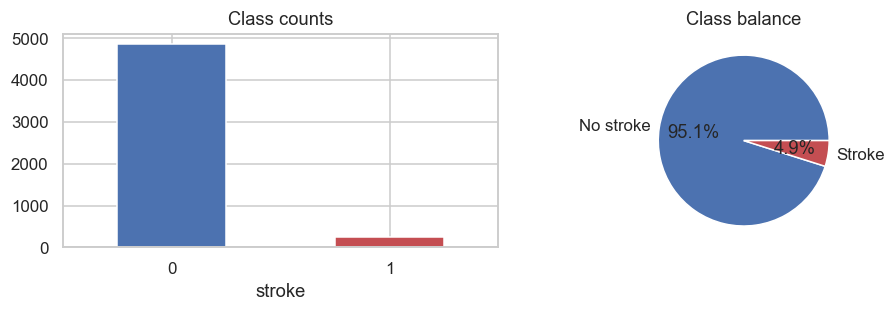

In [5]:
counts = df[TARGET].value_counts()
prevalence = df[TARGET].mean()

print(counts.to_string())
print(f"\nPrevalence: {prevalence*100:.2f}%  ({counts[1]} strokes in {len(df)} patients)")
print(f"Positives per 1,000 patients: {prevalence*1000:.1f}")
print(f"A 'nobody has a stroke' model would be {(1-prevalence)*100:.2f}% accurate.")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
df[TARGET].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Class counts"); ax[0].set_xlabel("stroke"); ax[0].set_xticklabels(["0", "1"], rotation=0)
ax[1].pie(counts, labels=["No stroke", "Stroke"], autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"])
ax[1].set_title("Class balance")
plt.tight_layout(); plt.show()

The target variable is highly imbalanced. Out of the 5,110 patients, only 249 experienced a stroke, corresponding to approximately 4.9% of the dataset, while 95.1% did not. This represents roughly a 1:19 ratio between stroke and non-stroke cases.

This imbalance is important because accuracy would be a misleading evaluation metric. A model that simply predicts “no stroke” for every patient would already achieve approximately 95.1% accuracy, despite failing to identify a single patient who actually experienced a stroke. Therefore, metrics that better capture performance on the minority class, particularly recall and AUPRC (Area Under the Precision-Recall Curve), will be more informative. We can also consider patient-impact counts, such as the number of true stroke cases detected and missed, to make model performance easier to interpret.

The imbalance also influences how we prepare and model the data. We will use stratified train, validation, and test splits so that each subset maintains approximately the same 4.9% stroke prevalence. This is especially important because there are only 249 positive cases; without stratification, some subsets could contain too few stroke cases to provide a reliable evaluation.

For handling the imbalance during training, class weighting may be preferable to immediately applying oversampling techniques such as SMOTE. With only 249 positive observations, synthetic oversampling would generate artificial examples from a relatively small group of real stroke patients, so its effect would need to be carefully validated rather than assumed to improve the model.

### 3.2 Univariate analysis

#### 3.2.1 Continuous variables

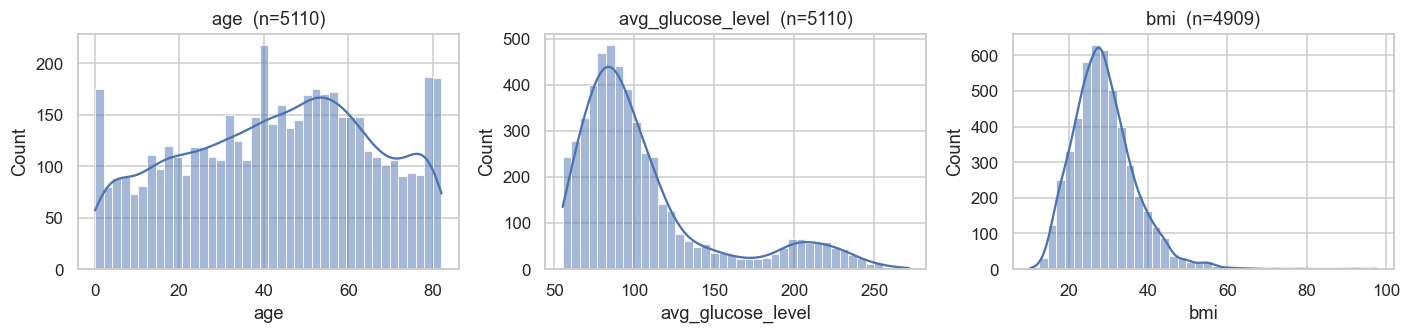

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.23,22.61,0.08,25.00,45.00,61.00,82.00
avg_glucose_level,5110.0,106.15,45.28,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.89,7.85,10.30,23.50,28.10,33.10,97.60


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}  (n={df[col].notna().sum()})")
plt.tight_layout(); plt.show()

df[NUM_COLS].describe().T.round(2)

The continuous variables have noticeably different distributions. `age` is broadly distributed across adulthood,
with an additional concentration of young children, so the full sample does not closely resemble an adult
screening-clinic population. `avg_glucose_level` has a bimodal distribution, with a large peak around 90 mg/dL
and a smaller peak above approximately 180 mg/dL. This may indicate that the sample contains distinct groups
with typical and substantially elevated glucose levels, although diagnosis status cannot be inferred from this
distribution alone. `bmi` is centred around 28–29 and has a long right tail, reaching a maximum of 97.6.

These patterns affect the later analysis. Glucose will be retained as a continuous variable and also examined in
clinically meaningful bands. Median imputation is more appropriate for missing BMI values because it is less
sensitive to the extreme upper tail. The presence of children is examined separately below before defining the
population used for modelling.

In [7]:
print("Patients under 18:", (df["age"] < 18).sum(), "| strokes among them:", int(df.loc[df["age"] < 18, TARGET].sum()))
print("Adults 18+:       ", (df["age"] >= 18).sum(), "| strokes among them:", int(df.loc[df["age"] >= 18, TARGET].sum()))
print(f"Prevalence in adults only: {df.loc[df['age'] >= 18, TARGET].mean()*100:.2f}%")

print("\nMean age by work_type:")
print(df.groupby("work_type")["age"].mean().round(1).sort_values().to_string())

Patients under 18: 856 | strokes among them: 2
Adults 18+:        4254 | strokes among them: 247
Prevalence in adults only: 5.81%

Mean age by work_type:
work_type
children          6.8
Never_worked     16.2
Private          45.5
Govt_job         50.9
Self-employed    60.2


Of the 5,110 patients, 856 (16.8%) are younger than 18, and only 2 of the 249 recorded strokes occur in this
group. Restricting the cohort to adults increases stroke prevalence from 4.87% to 5.81%. In addition, patients
with `work_type='children'` have a mean age of 6.8 years, showing that this category functions mainly as an
indirect indicator of age rather than an independent occupational characteristic.

Because the intended use case concerns adult outpatients, the main modelling analysis will be restricted to
patients aged 18 or older. This restriction should be reported explicitly as part of the cohort definition. It
also reduces the opportunity for the model to use the `children` category as a shortcut for identifying patients
with extremely low observed stroke prevalence.

#### 3.2.2 Binary variables

hypertension: 498 positive (9.7%)
heart_disease: 276 positive (5.4%)


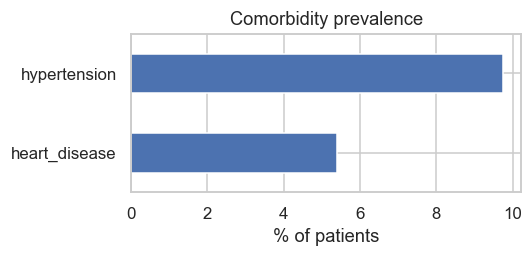

In [8]:
for col in BIN_COLS:
    n_pos = int(df[col].sum())
    print(f"{col}: {n_pos} positive ({n_pos/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 2.5))
df[BIN_COLS].mean().mul(100).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% of patients"); ax.set_title("Comorbidity prevalence")
plt.tight_layout(); plt.show()

Hypertension is recorded for 9.7% of patients and heart disease for 5.4%. These relatively low proportions may
partly reflect the young age distribution of the full dataset, but incomplete documentation is another possible
explanation. The available data do not allow these explanations to be separated.

The two variables should therefore be interpreted as indicators of a recorded diagnosis, rather than definitive
evidence that a patient does or does not have the condition. If documentation practices differ in another clinical
setting, the model's performance may also change, which is an important limitation for deployment.

#### 3.2.3 Categorical variables

In [9]:
for col in CAT_COLS:
    vc = df[col].value_counts(dropna=False)
    share = (vc / len(df) * 100).round(1)
    print(f"== {col}")
    print(pd.DataFrame({"n": vc, "%": share}).to_string(), "\n")

== gender
           n     %
Female  2994  58.6
Male    2115  41.4
Other      1   0.0 

== ever_married
        n     %
Yes  3353  65.6
No   1757  34.4 

== work_type
                  n     %
Private        2925  57.2
Self-employed   819  16.0
children        687  13.4
Govt_job        657  12.9
Never_worked     22   0.4 

== Residence_type
          n     %
Urban  2596  50.8
Rural  2514  49.2 

== smoking_status
                    n     %
never smoked     1892  37.0
Unknown          1544  30.2
formerly smoked   885  17.3
smokes            789  15.4 



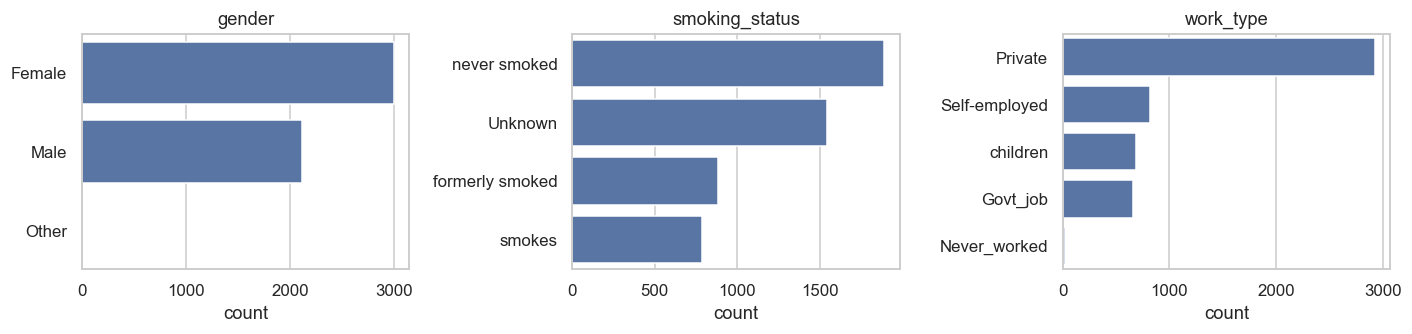

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ["gender", "smoking_status", "work_type"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4C72B0")
    ax.set_title(col); ax.set_ylabel("")
plt.tight_layout(); plt.show()

The categorical variables contain several unevenly represented groups. `gender='Other'` appears only once,
`work_type='Never_worked'` contains 22 patients, and `work_type='children'` contains 687 patients and largely
reflects age. In addition, smoking status is recorded as `Unknown` for 1,544 patients, or 30.2% of the dataset,
making it the second-largest smoking category.

The very small `Other` and `Never_worked` groups cannot support reliable subgroup performance estimates, and
reporting a rate for a single individual would also create a privacy concern. These records will be retained, but
their sample sizes will be reported instead of presenting unstable subgroup metrics. The large `Unknown` smoking
group requires further analysis because it represents a substantial and potentially systematic data-quality issue.

### 3.3 Missing values and "Unknown"

This section is where the two known data-quality issues get examined properly instead of being tidied away.
Both turn out to be more interesting than they look.

#### 3.3.1 `bmi` missing values

In [11]:
print(f"Overall: {df['bmi_missing'].sum()} missing BMI ({df['bmi_missing'].mean()*100:.1f}%)\n")

print("Stroke rate by whether BMI was recorded:")
print((df.groupby("bmi_missing")[TARGET].agg(n="size", strokes="sum", rate="mean")
         .assign(rate=lambda d: (d["rate"]*100).round(2)).to_string()), "\n")

print("Share of patients with missing BMI, by age band:")
print((df.groupby("age_band", observed=True)["bmi_missing"].mean()*100).round(1).to_string(), "\n")

print("Holding age constant (patients aged 60+):")
print(df[df["age"] >= 60].groupby("bmi_missing")[TARGET].agg(n="size", strokes="sum", rate="mean")
        .assign(rate=lambda d: (d["rate"]*100).round(2)).to_string())

Overall: 201 missing BMI (3.9%)

Stroke rate by whether BMI was recorded:
                n  strokes   rate
bmi_missing                      
0            4909      209   4.26
1             201       40  19.90 

Share of patients with missing BMI, by age band:
age_band
[0, 40)      2.6
[40, 50)     3.4
[50, 60)     3.5
[60, 70)     5.0
[70, 80)     9.8
[80, 100)    2.2 

Holding age constant (patients aged 60+):
                n  strokes   rate
bmi_missing                      
0            1285      150  11.67
1              91       31  34.07


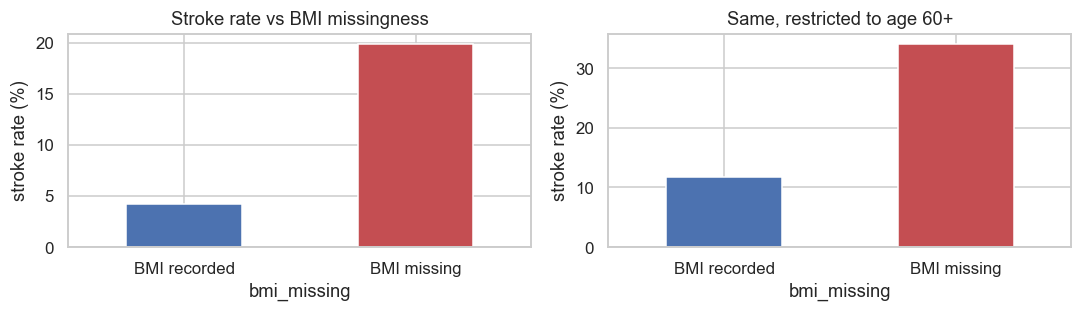

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
rates = df.groupby("bmi_missing")[TARGET].mean().mul(100)
rates.plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_xticklabels(["BMI recorded", "BMI missing"], rotation=0)
ax[0].set_ylabel("stroke rate (%)"); ax[0].set_title("Stroke rate vs BMI missingness")

sub = df[df["age"] >= 60].groupby("bmi_missing")[TARGET].mean().mul(100)
sub.plot(kind="bar", ax=ax[1], color=["#4C72B0", "#C44E52"])
ax[1].set_xticklabels(["BMI recorded", "BMI missing"], rotation=0)
ax[1].set_ylabel("stroke rate (%)"); ax[1].set_title("Same, restricted to age 60+")
plt.tight_layout(); plt.show()

BMI is missing for a clinically distinct group of patients. The stroke rate is 19.9% among patients with missing
BMI, compared with 4.3% among those with a recorded value. Age does not fully explain this difference: among
patients aged 60 or older, the corresponding rates are 34.1% and 11.7%. This indicates that BMI missingness is
not random with respect to the target.

One possible explanation is that BMI was less likely to be recorded for acutely unwell or less mobile patients,
meaning that missingness may partly reflect how and when the record was created. Because the data are
cross-sectional and contain no measurement timestamps, this possibility cannot be confirmed or excluded. It could be better to use median inputation in the training pipeline, but a `bmi_missing` indicator could introduce a documentation-related shortcut or leakage. Performance for patients
with imputed BMI will instead be assessed separately during error analysis.

#### 3.3.2 Who are the "Unknown" smokers?

In [13]:
unk = df["smoking_status"] == "Unknown"
print(f"Unknown smoking status: {unk.sum()} patients ({unk.mean()*100:.1f}%)")
print(f"Mean age — Unknown: {df.loc[unk,'age'].mean():.1f}   |   recorded: {df.loc[~unk,'age'].mean():.1f}\n")

print("Share 'Unknown' within each age band (%):")
print((df.groupby("age_band", observed=True)["smoking_status"]
         .apply(lambda s: (s == "Unknown").mean()*100)).round(1).to_string(), "\n")

print("Crude stroke rate by smoking status (%):")
print((df.groupby("smoking_status")[TARGET].mean()*100).round(2).to_string())

Unknown smoking status: 1544 patients (30.2%)
Mean age — Unknown: 30.2   |   recorded: 48.9

Share 'Unknown' within each age band (%):
age_band
[0, 40)      45.3
[40, 50)     20.7
[50, 60)     18.1
[60, 70)     18.4
[70, 80)     19.5
[80, 100)    18.8 

Crude stroke rate by smoking status (%):
smoking_status
Unknown            3.04
formerly smoked    7.91
never smoked       4.76
smokes             5.32


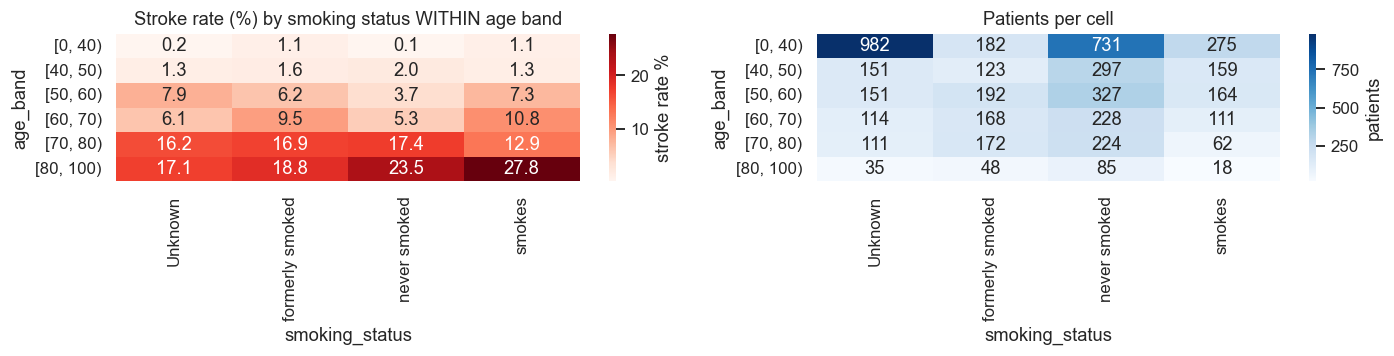

In [14]:
rate_by = (df.pivot_table(index="age_band", columns="smoking_status", values=TARGET,
                          aggfunc="mean", observed=True) * 100).round(1)
n_by = df.pivot_table(index="age_band", columns="smoking_status", values=TARGET,
                      aggfunc="size", observed=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
sns.heatmap(rate_by, annot=True, fmt=".1f", cmap="Reds", ax=ax[0], cbar_kws={"label": "stroke rate %"})
ax[0].set_title("Stroke rate (%) by smoking status WITHIN age band")
sns.heatmap(n_by, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar_kws={"label": "patients"})
ax[1].set_title("Patients per cell")
plt.tight_layout(); plt.show()

At first sight, patients with `smoking_status='Unknown'` have the lowest stroke rate: 3.0%, compared with 4.8%
for patients who never smoked and 7.9% for former smokers. However, the `Unknown` group is much younger, with
a mean age of 30 compared with 49 for the rest of the dataset. Approximately 45% of patients younger than 40
have an unknown smoking status, compared with about 19% in the older age bands. After stratifying by age, the
apparent protective association disappears; among patients in their 50s, the `Unknown` group has the highest
observed stroke rate at 7.9%.

This is consistent with Simpson's paradox: the crude association is driven by differences in age composition
rather than evidence that an unknown smoking status is protective. `Unknown` will be retained as a separate
category instead of being merged with `never smoked`, since the two groups are not interchangeable. Smoking
results should be interpreted within age groups, and model performance for the `Unknown` cohort will be
examined separately in the responsible-AI analysis.

### 3.4 Bivariate analysis

#### 3.4.1 Continuous variables vs the target

For each continuous variable we compare the distribution among patients with and without a recorded stroke,
using a t-test (means), Mann-Whitney U (distribution shift, no normality assumption) and Cohen's d.

In [15]:
def cont_tests(col: str) -> dict:
    a = df.loc[df[TARGET] == 0, col].dropna()
    b = df.loc[df[TARGET] == 1, col].dropna()
    t_stat, t_p = ttest_ind(a, b, equal_var=False)
    u_stat, u_p = mannwhitneyu(a, b, alternative="two-sided")
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return {"variable": col,
            "mean (no stroke)": round(a.mean(), 2), "mean (stroke)": round(b.mean(), 2),
            "median (no stroke)": round(a.median(), 2), "median (stroke)": round(b.median(), 2),
            "cohen_d": round((b.mean()-a.mean())/pooled, 3),
            "t p-value": f"{t_p:.2e}", "MWU p-value": f"{u_p:.2e}"}

pd.DataFrame([cont_tests(c) for c in NUM_COLS])

,variable,mean (no stroke),mean (stroke),median (no stroke),median (stroke),cohen_d,t p-value,MWU p-value
0,age,41.97,67.73,43.00,71.00,1.175,2.12e-95,3.73e-71
1,avg_glucose_level,104.80,132.54,91.47,105.22,0.618,2.40e-11,3.64e-09
2,bmi,28.82,30.47,28.00,29.70,0.210,3.34e-04,1.03e-04


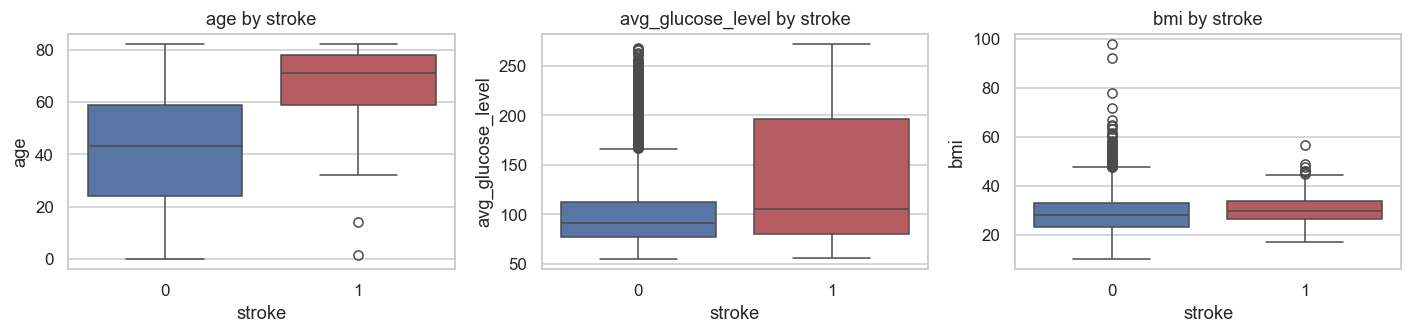

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["#4C72B0", "#C44E52"], hue=TARGET, legend=False)
    ax.set_title(f"{col} by stroke")
plt.tight_layout(); plt.show()

Age shows the largest difference between patients with and without a recorded stroke. The mean age is 67.7
years in the stroke group and 42.0 years in the non-stroke group, corresponding to a large effect size
(Cohen's d = 1.18). Average glucose level also differs meaningfully between the groups (132.5 versus 104.8
mg/dL; d = 0.62). BMI is statistically different (p ≈ 0.0001), but its effect size is small (d = 0.21),
showing that statistical significance does not necessarily imply strong discrimination between individuals.

These results suggest that age will be the dominant predictor, with glucose providing additional information and
BMI contributing more weakly. The later modelling analysis should therefore assess whether a multivariable model
adds useful information beyond age alone, rather than assuming that improved fit automatically translates into a
clinically useful risk-stratification tool.

#### 3.4.2 Binary and categorical variables vs the target

Here we ask whether the stroke rate differs between groups. We report each group's rate with a **95% Wilson
confidence interval** plus a chi-squared test of
independence.

In [17]:
def wilson_interval(successes: int, total: int, confidence: float = 0.95):
    """Wilson score interval — behaves sensibly for small n and rates near 0."""
    if total == 0:
        return (np.nan, np.nan)
    z = 1.959963984540054 if confidence == 0.95 else abs(np.sqrt(2) * 1.0)
    p = successes / total
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2*total)) / denom
    half = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def rate_table(col: str) -> pd.DataFrame:
    rows = []
    for value, g in df.groupby(col, observed=True):
        k, n = int(g[TARGET].sum()), len(g)
        lo, hi = wilson_interval(k, n)
        rows.append({col: value, "n": n, "strokes": k, "rate %": round(100*k/n, 2),
                     "95% CI low": round(100*lo, 2), "95% CI high": round(100*hi, 2)})
    tab = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(tab)
    out = pd.DataFrame(rows)
    print(f"== {col}   chi-squared p = {p:.3g}")
    return out


for c in BIN_COLS + CAT_COLS:
    display(rate_table(c))

== hypertension   chi-squared p = 1.66e-19


,hypertension,n,strokes,rate %,95% CI low,95% CI high
0,0,4612,183,3.97,3.44,4.57
1,1,498,66,13.25,10.55,16.51


== heart_disease   chi-squared p = 2.09e-21


,heart_disease,n,strokes,rate %,95% CI low,95% CI high
0,0,4834,202,4.18,3.65,4.78
1,1,276,47,17.03,13.05,21.91


== gender   chi-squared p = 0.79


...

,work_type,n,strokes,rate %,95% CI low,95% CI high
0,Govt_job,657,33,5.02,3.60,6.97
1,Never_worked,22,0,0.00,0.00,14.87
2,Private,2925,149,5.09,4.35,5.95
3,Self-employed,819,65,7.94,6.28,9.99
4,children,687,2,0.29,0.08,1.06


== Residence_type   chi-squared p = 0.298


,Residence_type,n,strokes,rate %,95% CI low,95% CI high
0,Rural,2514,114,4.53,3.79,5.42
1,Urban,2596,135,5.20,4.41,6.12


== smoking_status   chi-squared p = 2.09e-06


,smoking_status,n,strokes,rate %,95% CI low,95% CI high
0,Unknown,1544,47,3.04,2.30,4.02
1,formerly smoked,885,70,7.91,6.31,9.88
2,never smoked,1892,90,4.76,3.89,5.81
3,smokes,789,42,5.32,3.96,7.12


In [18]:
display(rate_table("age_band"))
display(rate_table("glucose_band"))

== age_band   chi-squared p = 2.87e-84


,age_band,n,strokes,rate %,95% CI low,95% CI high
0,"[0, 40)",2170,8,0.37,0.19,0.73
1,"[40, 50)",730,12,1.64,0.94,2.85
2,"[50, 60)",834,48,5.76,4.37,7.55
3,"[60, 70)",621,47,7.57,5.74,9.92
4,"[70, 80)",569,94,16.52,13.70,19.79
5,"[80, 100)",186,40,21.51,16.21,27.95


== glucose_band   chi-squared p = 1.23e-18


,glucose_band,n,strokes,rate %,95% CI low,95% CI high
0,<100 (normal),3131,112,3.58,2.98,4.29
1,100-126 (pre-diabetic),998,37,3.71,2.70,5.07
2,126-200 (diabetic range),547,44,8.04,6.05,10.63
3,>200 (very high),434,56,12.90,10.07,16.39


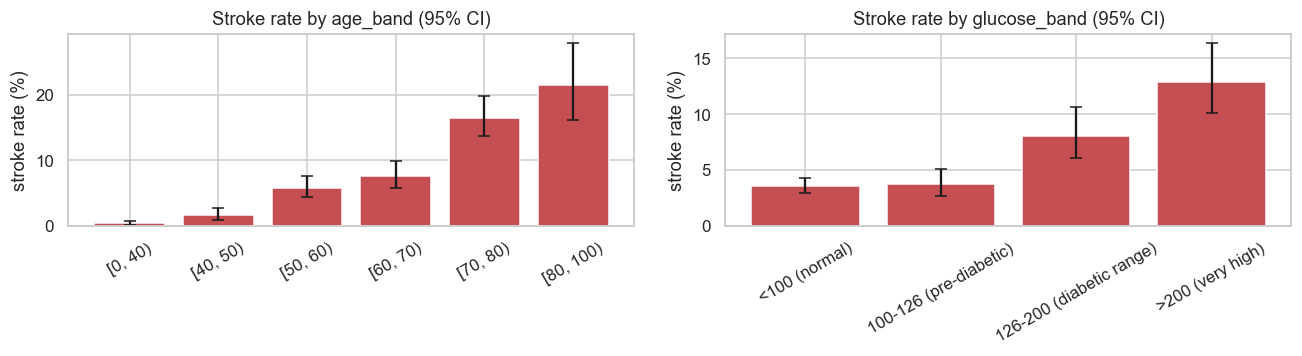

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, col in zip(axes, ["age_band", "glucose_band"]):
    t = df.groupby(col, observed=True)[TARGET].agg(["mean", "size"]).reset_index()
    err = [[100*(t["mean"][i] - wilson_interval(int(t["mean"][i]*t["size"][i]), int(t["size"][i]))[0]) for i in t.index],
           [100*(wilson_interval(int(t["mean"][i]*t["size"][i]), int(t["size"][i]))[1] - t["mean"][i]) for i in t.index]]
    ax.bar(t[col].astype(str), t["mean"]*100, yerr=err, capsize=4, color="#C44E52")
    ax.set_ylabel("stroke rate (%)"); ax.set_title(f"Stroke rate by {col} (95% CI)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Stroke prevalence increases markedly across age bands, from 0.4% among patients younger than 40 to 5.8% among
those in their 50s, 16.5% among those in their 70s, and 21.5% among those aged 80 or older. The rate remains
relatively low across the lower glucose bands and then rises to 8.0% in the 126–199 mg/dL band and 12.9% above
200 mg/dL. Recorded hypertension is associated with a stroke rate of 13.3%, compared with 4.0% without
hypertension, while the corresponding rates for heart disease are 17.0% and 4.2%.

Several categorical variables also show differences in their unadjusted stroke rates. Patients who had ever
married have a rate of 6.56%, compared with 1.65% among those who had not (p < 0.001). This should not be
interpreted as evidence that marriage increases stroke risk: the married group is older, and the odds ratio falls
from 2.03 to 0.97 after age adjustment. Marital status therefore behaves mainly as a proxy for age in this
dataset.

Stroke rates also vary across `work_type` (p < 0.001). The highest rate occurs among self-employed patients
(7.94%), followed by private-sector (5.09%) and government-employed patients (5.02%). The rate is 0.29% for
the `children` category, while none of the 22 patients in `Never_worked` experienced a stroke. These differences
largely reflect the age composition of the groups: self-employed patients are older on average, `children` is
effectively an age category, and the `Never_worked` estimate is too imprecise to interpret. Consistent with this,
the odds ratio for self-employment changes from 1.26 to 0.87 after age adjustment.

For `smoking_status`, former smokers have the highest crude stroke rate at 7.91%, followed by current smokers
at 5.32%, patients who never smoked at 4.76%, and patients with an unknown status at 3.04% (p < 0.001). The
apparently low rate in the `Unknown` group is strongly influenced by its younger age distribution, as shown in
Section 3.3.2. After age adjustment, the odds ratio is 1.14 for having ever smoked and 0.83 for an unknown
status, so the crude category differences should not be interpreted as causal effects. `Unknown` should remain
a separate category because it reflects a distinct recording pattern rather than confirmed non-smoking.

In contrast, `gender` and `Residence_type` show little evidence of an association with stroke. The observed rates
are 4.71% for women and 5.11% for men (p = 0.79), and 4.53% for rural residents compared with 5.20% for
urban residents (p = 0.30). Their adjusted odds ratios are also close to one (`male` = 0.99 and `urban` =
1.00). Age, glucose, hypertension and heart disease therefore contain the clearest signal, while marital status,
work type and unknown smoking status require particular caution because they partly encode age. These remain
associations rather than causal effects, and the next section examines them jointly in a multivariable model.

### 3.5 Multivariate analysis — how much of this is just age?

The single most important question in this dataset. Several variables look predictive on their own; the test
is whether they still say anything **once age is accounted for**.

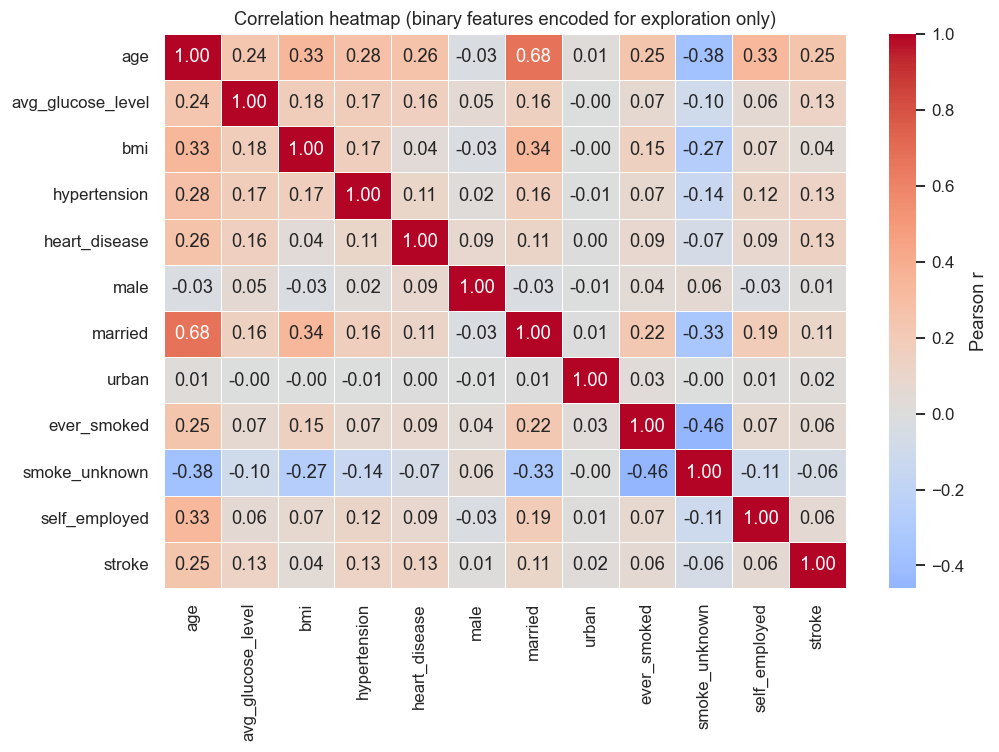

Spearman correlation with stroke, ranked:
age                  0.250
heart_disease        0.135
hypertension         0.128
married              0.108
avg_glucose_level    0.083
self_employed        0.062
ever_smoked          0.059
bmi                  0.055
urban                0.015
male                 0.009
smoke_unknown       -0.056


In [20]:
enc = df.copy()
enc["male"] = (enc["gender"] == "Male").astype(int)
enc["married"] = (enc["ever_married"] == "Yes").astype(int)
enc["urban"] = (enc["Residence_type"] == "Urban").astype(int)
enc["ever_smoked"] = enc["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int)
enc["smoke_unknown"] = (enc["smoking_status"] == "Unknown").astype(int)
enc["self_employed"] = (enc["work_type"] == "Self-employed").astype(int)

corr_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
             "male", "married", "urban", "ever_smoked", "smoke_unknown", "self_employed", TARGET]

plt.figure(figsize=(9.5, 7))
sns.heatmap(enc[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation heatmap (binary features encoded for exploration only)")
plt.tight_layout(); plt.show()

print("Spearman correlation with stroke, ranked:")
print(enc[corr_cols].corr(method="spearman")[TARGET].drop(TARGET)
        .sort_values(ascending=False).round(3).to_string())

No individual feature has a strong linear correlation with `stroke`. Age has the largest correlation at r = 0.25,
followed by heart disease and hypertension at approximately r = 0.13. These modest values are not unexpected
for a binary outcome with a prevalence of about 5%, and they do not rule out useful multivariable patterns.

The relationships among predictors are more substantial. `ever_married` and age correlate at r = 0.68, while
`smoke_unknown` correlates with age at r = −0.38 and BMI correlates with age at r = 0.33. This indicates that
several apparent risk factors may partly act as proxies for age. In particular, the crude association between marital status and
stroke should not be interpreted independently before age adjustment.

In [21]:
model_df = enc.dropna(subset=["bmi"]).copy()   # exploration only; the real model imputes inside the pipeline

def odds_ratio(cols):
    X = StandardScaler().fit_transform(model_df[cols])
    m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X, model_df[TARGET])
    return pd.Series(np.exp(m.coef_[0]), index=cols)

rows = []
for c in ["married", "self_employed", "ever_smoked", "smoke_unknown",
          "hypertension", "heart_disease", "avg_glucose_level", "bmi"]:
    rows.append({"feature": c,
                 "OR (alone)": round(odds_ratio([c])[c], 2),
                 "OR (age-adjusted)": round(odds_ratio(["age", c])[c], 2)})

print("Odds ratios per 1 SD — before and after adjusting for age\n")
print(pd.DataFrame(rows).to_string(index=False))

Odds ratios per 1 SD — before and after adjusting for age

          feature  OR (alone)  OR (age-adjusted)
          married        2.03               0.97
    self_employed        1.26               0.87
      ever_smoked        1.33               1.14
    smoke_unknown        0.63               0.83
     hypertension        1.54               1.21
    heart_disease        1.43               1.12
avg_glucose_level        1.65               1.28
              bmi        1.21               1.13


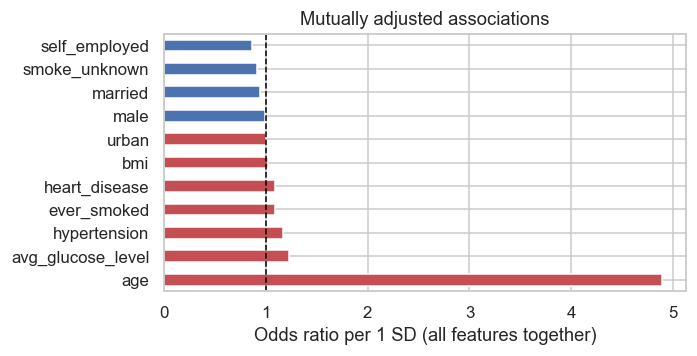

age                  4.886
avg_glucose_level    1.228
hypertension         1.166
ever_smoked          1.092
heart_disease        1.086
bmi                  1.021
urban                1.004
male                 0.991
married              0.939
smoke_unknown        0.918
self_employed        0.869


In [22]:
full = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
        "male", "married", "ever_smoked", "smoke_unknown", "self_employed", "urban"]
ors = odds_ratio(full).sort_values(ascending=False)

plt.figure(figsize=(6.5, 3.4))
colors = ["#C44E52" if v > 1 else "#4C72B0" for v in ors]
ors.plot(kind="barh", color=colors)
plt.axvline(1.0, color="black", lw=1, ls="--")
plt.xlabel("Odds ratio per 1 SD (all features together)")
plt.title("Mutually adjusted associations")
plt.tight_layout(); plt.show()

print(ors.round(3).to_string())

Age adjustment changes several of the univariate associations substantially. The odds ratio for `ever_married`
falls from 2.03 to 0.97 after adjustment, indicating that its crude association with stroke is explained almost
entirely by age. The odds ratio for `self_employed` similarly changes from 1.26 to 0.87, while the estimate for
`smoke_unknown` moves from 0.63 to 0.83, confirming that much of its apparent protective association reflects
the younger age of that group. Glucose (1.65 to 1.28), hypertension (1.54 to 1.21), heart disease (1.43 to
1.12), and BMI (1.21 to 1.13) retain smaller positive associations after age adjustment. In the mutually
adjusted model, age has an odds ratio of approximately 4.9 per standard deviation, whereas all other estimates
lie between 0.87 and 1.23.

These estimates describe associations in a single cross-sectional dataset and should not be interpreted as causal
effects. Overall, the results indicate that a model fitted to these data will be driven primarily by age, with
smaller corrections from the remaining variables. Its usefulness should therefore be judged against an age-only
benchmark. Marital status and work type must be interpreted cautiously as possible age proxies, and the feature-
importance analysis should verify whether the fitted model relies on them.

### 3.6 Subgroup and fairness-relevant slices

These are the slices we'll have to report on later, so we check now whether they're even large enough to
support a metric.

In [23]:
pivot_rate = (df.pivot_table(index="age_band", columns="gender", values=TARGET,
                             aggfunc="mean", observed=True) * 100).round(1)
pivot_n = df.pivot_table(index="age_band", columns="gender", values=TARGET, aggfunc="size", observed=True)

print("Stroke rate (%) by age band x gender:"); print(pivot_rate.to_string())
print("\nPatients per cell:"); print(pivot_n.to_string())

print("\nIntersection — age 60+ and hypertension:")
print(df[df["age"] >= 60].groupby("hypertension")[TARGET]
        .agg(n="size", strokes="sum", rate="mean").assign(rate=lambda d: (d["rate"]*100).round(1)).to_string())

print("\nSmallest subgroups (these cannot carry a fairness metric):")
for col in ["gender", "work_type", "smoking_status"]:
    vc = df[col].value_counts()
    small = vc[vc < 100]
    for k, v in small.items():
        print(f"  {col} = {k!r}: n={v}, strokes={int(df.loc[df[col]==k, TARGET].sum())}")

Stroke rate (%) by age band x gender:
gender     Female  Male  Other
age_band                      
[0, 40)       0.6   0.0    0.0
[40, 50)      1.3   2.1    NaN
[50, 60)      5.5   6.1    NaN
[60, 70)      6.2   9.3    NaN
[70, 80)     17.0  15.9    NaN
[80, 100)    19.5  24.7    NaN

Patients per cell:
gender     Female   Male  Other
age_band                       
[0, 40)    1271.0  898.0    1.0
[40, 50)    450.0  280.0    NaN
[50, 60)    472.0  362.0    NaN
[60, 70)    352.0  269.0    NaN
[70, 80)    336.0  233.0    NaN
[80, 100)   113.0   73.0    NaN

Intersection — age 60+ and hypertension:
                 n  strokes  rate
hypertension                     
0             1080      128  11.9
1              296       53  17.9

Smallest subgroups (these cannot carry a fairness metric):
  gender = 'Other': n=1, strokes=0
  work_type = 'Never_worked': n=22, strokes=0


Stroke rates are broadly similar between men and women within most age bands, although men have somewhat higher
observed rates in their 60s (9.3% versus 6.3%) and at age 80 or older (24.7% versus 19.5%), while women have a
higher rate in their 70s. Among patients aged 60 or older, those with recorded hypertension have a stroke rate
of 17.9%, compared with 11.9% among those without hypertension; this subgroup contains 296 patients.

Some categories remain too small for meaningful evaluation. `gender='Other'` contains one patient,
`work_type='Never_worked'` contains 22, and some age-by-gender cells are also limited, including 73 men aged 80
or older. Subgroup metrics for these categories would be unstable, and the single-person category also raises a
privacy concern. The responsible-AI analysis will therefore focus primarily on older patients with hypertension
and secondarily on patients with unknown smoking status. All reported subgroup results should include sample
sizes and confidence intervals, while under-represented groups should be identified as unevaluable rather than
silently omitted.

## 4. Takeaways

This is an age-dominated dataset with a handful of genuine secondary signals and two
data-quality issues that are interesting.

Main Features we keep:

- Age
- Avg glucose level
- Hypertension
- Heart disease
- BMI
- Smoking status
- Gender

## 5. Modeling Setup

Section 3.x already set `RANDOM_STATE`, `TARGET`, `NUM_COLS`, `BIN_COLS`, `CAT_COLS` and the 
core imports. This adds only what's needed for splitting, pipelines and the baseline model.

In [24]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold

from utils import positive_scores, auc_report

## 6. Data preparation for modeling

The EDA identified one row with `gender='Other'` (Section 3.2.3), too small a group to support 
any subgroup metric, so it's dropped here before modeling. `bmi` missingness is handled inside 
the pipeline (Section 7.2), not here, to avoid leakage

In [ ]:
df_model = df[(df["gender"] != "Other") & (df["age"] >= 18)].reset_index(drop=True)
print(f"Records for modeling: {len(df_model):,} "
      f"(dropped {len(df) - len(df_model)} records: 1 'Other' gender row + patients under 18)")

Records for modeling: 5,109 (dropped 1 'Other' gender row)


## 7. Training, Validation and Testing — 70/15/15 stratified split

Stratified on `stroke` given the ~4.9% prevalence confirmed in Section 3.1. This dataset is 
single-source and cross-sectional, with no site or timestamp columns available, so a 
temporal or site-aware split isn't possible 
here

In [26]:
X = df_model[NUM_COLS + BIN_COLS + CAT_COLS].copy()
y = df_model[TARGET].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

def split_summary(name, y_part):
    counts = y_part.value_counts().reindex([0, 1], fill_value=0)
    return {"Set": name, "Records": len(y_part),
            "No stroke": int(counts[0]), "Stroke cases": int(counts[1]),
            "Stroke rate": float(counts[1] / len(y_part))}

display(pd.DataFrame([
    split_summary("Train", y_train),
    split_summary("Validation", y_val),
    split_summary("Overall", y),
]).style.hide(axis="index").format({"Stroke rate": "{:.3f}"}))

print(f"Test set reserved: {len(X_test)} records; stays closed until Step 8")

Set,Records,No stroke,Stroke cases,Stroke rate
Train,3576,3402,174,0.049
Validation,766,729,37,0.048
Overall,5109,4860,249,0.049


Test set reserved: 767 records; stays closed until Step 8


### 7.1. Baseline

Dummy baseline
PR AUC: 0.048
ROC AUC: 0.500
Stroke prevalence: 0.048
PR AUC relative to prevalence baseline: 1.00 times


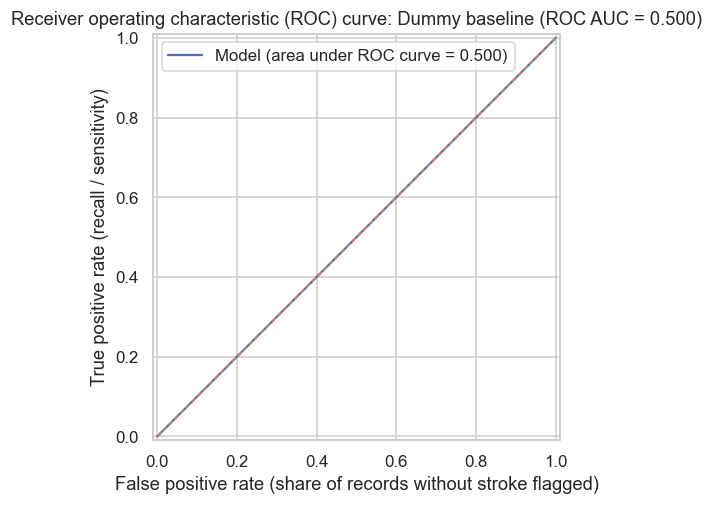

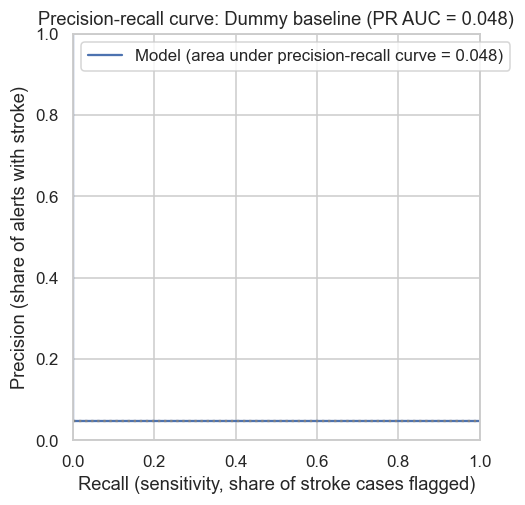

In [27]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

y_score_val = positive_scores(dummy_clf, X_val)
metrics_dummy = auc_report(y_val, y_score_val, name="Dummy baseline", plot=True, label="stroke")

### 7.2. Preprocessing pipeline

base_clf
PR AUC: 0.290
ROC AUC: 0.843
Stroke prevalence: 0.048
PR AUC relative to prevalence baseline: 6.00 times


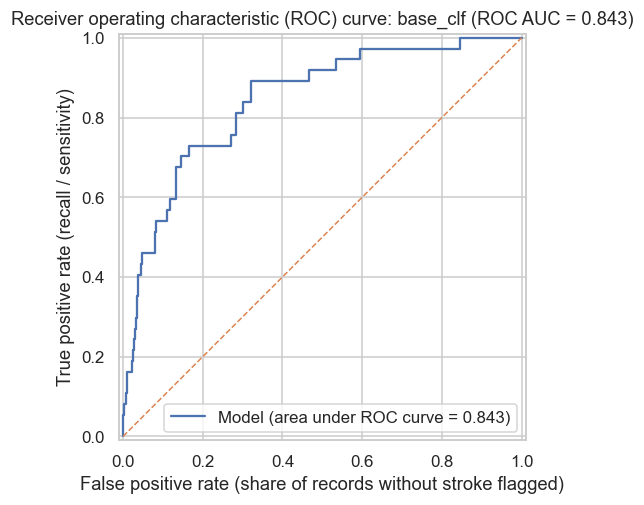

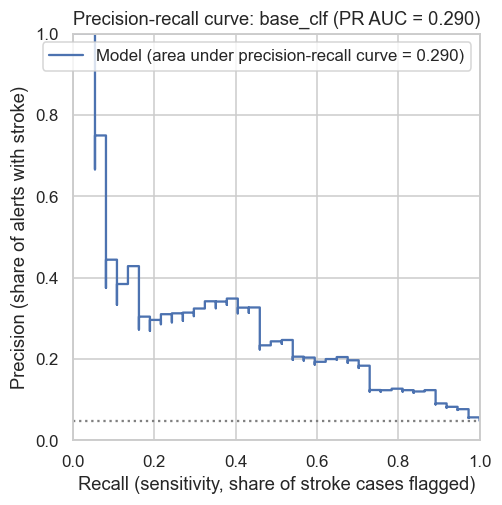

In [28]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUM_COLS),
    ("bin", binary_transformer, BIN_COLS),
    ("nom", nominal_transformer, CAT_COLS),
], remainder="drop")

base_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("varth", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE, max_iter=500))
])

base_clf.fit(X_train, y_train)
y_score_val = positive_scores(base_clf, X_val)
metrics_base = auc_report(y_val, y_score_val, name="base_clf", plot=True, label="stroke")

#### 7.2.1 Leakage check

The preprocessing pipeline is fit only via `base_clf.fit(X_train, y_train)`, so every 
imputation statistic and scaling parameter should be derived from `X_train` alone. Confirming 
that here rather than just asserting it

In [29]:
fitted_imputer_stats = base_clf.named_steps["prep"].named_transformers_["num"].named_steps["imputer"].statistics_
train_medians = X_train[NUM_COLS].median().values

print("Numeric columns:", NUM_COLS)
print("Imputer's learned medians:      ", fitted_imputer_stats)
print("Actual train-set medians:       ", train_medians)
print("Match (leakage-free imputation):", np.allclose(fitted_imputer_stats, train_medians, equal_nan=True))

# Sanity check: these should differ from the full-dataset median if there's any distributional
# shift between train and the held-out val/test — proving the pipeline didn't peek at them
full_dataset_medians = df_model[NUM_COLS].median().values
print("\nFull-dataset medians (for comparison, NOT what the pipeline used):", full_dataset_medians)

Numeric columns: ['age', 'avg_glucose_level', 'bmi']
Imputer's learned medians:       [45.    91.695 27.9  ]
Actual train-set medians:        [45.    91.695 27.9  ]
Match (leakage-free imputation): True

Full-dataset medians (for comparison, NOT what the pipeline used): [45.   91.88 28.1 ]
